In [ ]:
#para mandar João Henrique Martins de Souza Sena
def regra_extremidade_esquerda(a=1, b=1, c=1, d=1, e=1, f=1, h=0.25, xi=2, xf=3, plot=True):
    intervalo = []
    for i in range(int((xf - xi) / h)):
        intervalo.append(xi + i * h)

    fxi = []
    ci_fxi = []
    for x in intervalo:
        fx = a * x**5 + b * x**4 + c * x**3 + d * x**2 - e * x + f
        fxi.append(fx)
        ci_fxi.append(fx * h)

    somatorio = sum(ci_fxi)

    integral_xf = (a/6)*xf**6 + (b/5)*xf**5 + (c/4)*xf**4 + (d/3)*xf**3 - (e/2)*xf**2 + f*xf
    integral_xi = (a/6)*xi**6 + (b/5)*xi**5 + (c/4)*xi**4 + (d/3)*xi**3 - (e/2)*xi**2 + f*xi
    integral_analitica = integral_xf - integral_xi

    derivada_primeira = 5 * a * x**4 + 4 * b * x**3 + 3 * c * x**2 + 2 * d * x - e
    derivada_segunda = 20 * a * x**3 + 12 * b * x**2 + 6 * c * x + 2 * d

    

    dicionario = {
        'intervalo': intervalo,
        'f(x)': fxi,
        'integral numérica': somatorio,
        'integral analítica': integral_analitica,
        'primeira derivada': derivada_primeira,
        'segunda derivada': derivada_segunda
    }

    if plot == True:
        import matplotlib.pyplot as plt
        plt.plot(intervalo, fxi, 'bo-', label='f(x)')
        plt.title('Regra da Ext. Esquerda')
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.grid(True)
        plt.legend()
        plt.show()

    return dicionario


In [1]:
def regressao_linear(x, y, plot=True):
    if len(x) != len(y):
        raise ValueError("As listas x e y devem ter o mesmo tamanho.")
    
    n = len(x)

    soma_x = sum(x)
    soma_y = sum(y)
    soma_xy = sum([x[i] * y[i] for i in range(n)])
    soma_x2 = sum([xi**2 for xi in x])

    m = (n * soma_xy - soma_x * soma_y) / (n * soma_x2 - soma_x**2)   # inclinação
    b = (soma_y - m * soma_x) / n                                     # intercepto

    y_estimado = [m * xi + b for xi in x]

    sq_residuos = sum([(y[i] - y_estimado[i])**2 for i in range(n)])

    media_y = soma_y / n
    sq_total = sum([(yi - media_y)**2 for yi in y])

    r2 = 1 - sq_residuos / sq_total if sq_total != 0 else 0

    dicionario = {
        "coeficiente angular (m)": m,
        "coeficiente linear (b)": b,
        "y estimado": y_estimado,
        "R²": r2,
        "resíduos": [y[i] - y_estimado[i] for i in range(n)]
    }

    if plot:
        import matplotlib.pyplot as plt

        plt.scatter(x, y, label="Pontos originais")
        plt.plot(x, y_estimado, 'r-', label="Reta ajustada")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Regressão Linear Simples")
        plt.grid(True)
        plt.legend()
        plt.show()

    return dicionario

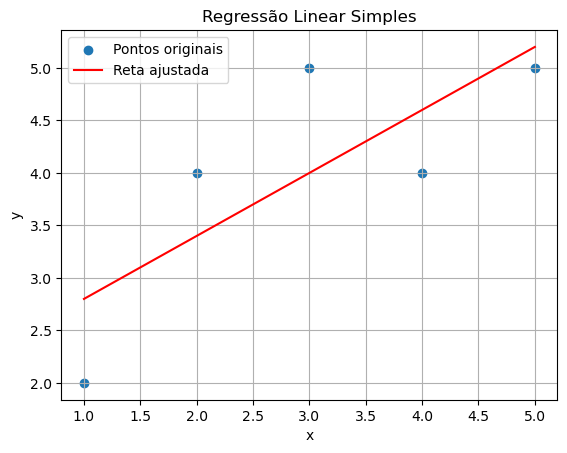

{'coeficiente angular (m)': 0.6, 'coeficiente linear (b)': 2.2, 'y estimado': [2.8000000000000003, 3.4000000000000004, 4.0, 4.6, 5.2], 'R²': 0.6000000000000001, 'resíduos': [-0.8000000000000003, 0.5999999999999996, 1.0, -0.5999999999999996, -0.20000000000000018]}


In [2]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 4, 5]

resultado = regressao_linear(x, y, plot=True)

print(resultado)